<a href="https://colab.research.google.com/github/Ruhul73/Titanic-ship-/blob/main/Titanic_ship.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Titanic Survival Prediction: End-to-End Machine Learning Project

This notebook demonstrates a complete machine learning pipeline for predicting Titanic survival, from data loading and preprocessing to model training, evaluation, and comparison.

In [ ]:
# Install dependencies as needed:
# pip install kagglehub[pandas-datasets]
import kagglehub
from kagglehub import KaggleDatasetAdapter

# Set the path to the file you'd like to load
file_path = "train.csv"

# Load the latest version using dataset_load() as recommended
df = kagglehub.dataset_load(
  KaggleDatasetAdapter.PANDAS,
  "zain280/titanic-data-set",
  file_path,
  # Provide any additional arguments like
  # sql_query or pandas_kwargs. See the
  # documenation for more information:
  # https://github.com/Kaggle/kagglehub/blob/main/README.md#kaggledatasetadapterpandas
)

print("First 5 records:", df.head())

100%|██████████| 59.8k/59.8k [00:00<00:00, 33.1MB/s]

First 5 records:    PassengerId  Survived  Pclass  \
0            1         0       3   
1            2         1       1   
2            3         1       3   
3            4         1       1   
4            5         0       3   

                                                Name     Sex   Age  SibSp  \
0                            Braund, Mr. Owen Harris    male  22.0      1   
1  Cumings, Mrs. John Bradley (Florence Briggs Th...  female  38.0      1   
2                             Heikkinen, Miss. Laina  female  26.0      0   
3       Futrelle, Mrs. Jacques Heath (Lily May Peel)  female  35.0      1   
4                           Allen, Mr. William Henry    male  35.0      0   

   Parch            Ticket     Fare Cabin Embarked  
0      0         A/5 21171   7.2500   NaN        S  
1      0          PC 17599  71.2833   C85        C  
2      0  STON/O2. 3101282   7.9250   NaN        S  
3      0            113803  53.1000  C123        S  
4      0            373450   8.0500   

## Data Preprocessing

This section focuses on cleaning and transforming the raw data into a suitable format for machine learning models. This includes handling missing values, encoding categorical features, and dropping irrelevant columns.

## Data Preprocessing

In [ ]:
import pandas as pd
from IPython.display import display

print("Initial DataFrame shape:", df.shape)
print("\nMissing values before preprocessing:")
print(df.isnull().sum())

Initial DataFrame shape: (891, 12)

Missing values before preprocessing:
PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64


### Handling Missing Values and Dropping Irrelevant Features

We first inspect the number of missing values for each column. We will impute missing 'Age' values with the median and 'Embarked' values with the mode. Columns such as 'Cabin' (too many missing values), 'PassengerId', 'Name', and 'Ticket' (irrelevant for prediction) will be dropped.

In [ ]:
# Handle missing 'Age' values with the median
df['Age'].fillna(df['Age'].median(), inplace=True)

# Handle missing 'Embarked' values with the most frequent value (mode)
df['Embarked'].fillna(df['Embarked'].mode()[0], inplace=True)

# Drop 'Cabin', 'PassengerId', 'Name', and 'Ticket' columns
df.drop(['Cabin', 'PassengerId', 'Name', 'Ticket'], axis=1, inplace=True)

print("\nMissing values after handling:")
print(df.isnull().sum())


Missing values after handling:
Survived    0
Pclass      0
Sex         0
Age         0
SibSp       0
Parch       0
Fare        0
Embarked    0
dtype: int64


/tmp/ipykernel_1982/2257865910.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['Age'].fillna(df['Age'].median(), inplace=True)
/tmp/ipykernel_1982/2257865910.py:5: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', tr

### Encoding Categorical Features

Categorical features like 'Sex' and 'Embarked' need to be converted into numerical representations. We will use one-hot encoding for this purpose, specifically `pd.get_dummies` with `drop_first=True` to avoid multicollinearity.

In [ ]:
# Encode categorical features: 'Sex' and 'Embarked'
df = pd.get_dummies(df, columns=['Sex', 'Embarked'], drop_first=True)

print("\nDataFrame head after preprocessing:")
display(df.head())


DataFrame head after preprocessing:


,Survived,Pclass,Age,SibSp,Parch,Fare,Sex_male,Embarked_Q,Embarked_S
0,0,3,22.0,1,0,7.2500,True,False,True
1,1,1,38.0,1,0,71.2833,False,False,False
2,1,3,26.0,0,0,7.9250,False,False,True
3,1,1,35.0,1,0,53.1000,False,False,True
4,0,3,35.0,0,0,8.0500,True,False,True


### Final Data Information

Let's verify the DataFrame's structure and ensure all features are in the correct data types after preprocessing.

In [ ]:
print("\nDataFrame information after preprocessing:")
print(df.info())


DataFrame information after preprocessing:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 9 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Survived    891 non-null    int64  
 1   Pclass      891 non-null    int64  
 2   Age         891 non-null    float64
 3   SibSp       891 non-null    int64  
 4   Parch       891 non-null    int64  
 5   Fare        891 non-null    float64
 6   Sex_male    891 non-null    bool   
 7   Embarked_Q  891 non-null    bool   
 8   Embarked_S  891 non-null    bool   
dtypes: bool(3), float64(2), int64(4)
memory usage: 44.5 KB
None


### Feature Scaling

Many machine learning algorithms perform better when numerical input variables are scaled to a standard range. For instance, algorithms that compute distances between data points (like K-Nearest Neighbors and Support Vector Machines) are particularly sensitive to the scale of features. We will use `StandardScaler` to transform our numerical features so they have a mean of 0 and a standard deviation of 1.

In [ ]:
from sklearn.preprocessing import StandardScaler

# Initialize StandardScaler
scaler = StandardScaler()

# Identify numerical features to scale (Age, SibSp, Parch, Fare)
# Note: 'Survived' is the target, 'Pclass' is categorical (one-hot encoded as True/False), 'Sex_male', 'Embarked_Q', 'Embarked_S' are already binary.
numerical_cols = ['Age', 'SibSp', 'Parch', 'Fare']

# Apply scaling to the numerical features in the DataFrame
df[numerical_cols] = scaler.fit_transform(df[numerical_cols])

print("\nDataFrame head after feature scaling:")
display(df.head())


DataFrame head after feature scaling:


,Survived,Pclass,Age,SibSp,Parch,Fare,Sex_male,Embarked_Q,Embarked_S
0,0,3,-0.565736,0.432793,-0.473674,-0.502445,True,False,True
1,1,1,0.663861,0.432793,-0.473674,0.786845,False,False,False
2,1,3,-0.258337,-0.474545,-0.473674,-0.488854,False,False,True
3,1,1,0.433312,0.432793,-0.473674,0.420730,False,False,True
4,0,3,0.433312,-0.474545,-0.473674,-0.486337,True,False,True


## Model Training and Evaluation

In this section, we prepare the data for training, split it into training and testing sets, train several classification models, and evaluate their performance using various metrics and confusion matrices.

## Model Training and Evaluation

In [ ]:
from sklearn.model_selection import train_test_split

# Define features (X) and target (y)
X = df.drop('Survived', axis=1)
y = df['Survived']

# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"X_train shape: {X_train.shape}")
print(f"X_test shape: {X_test.shape}")
print(f"y_train shape: {y_train.shape}")
print(f"y_test shape: {y_test.shape}")

X_train shape: (712, 8)
X_test shape: (179, 8)
y_train shape: (712,)
y_test shape: (179,)


### Data Splitting

We will define our features (X) and target variable (y). Then, the dataset will be split into training (80%) and testing (20%) sets to ensure our models are evaluated on unseen data.


Training Logistic Regression...
Logistic Regression - Accuracy: 0.7989, Precision: 0.7879, Recall: 0.7027, F1-Score: 0.7429


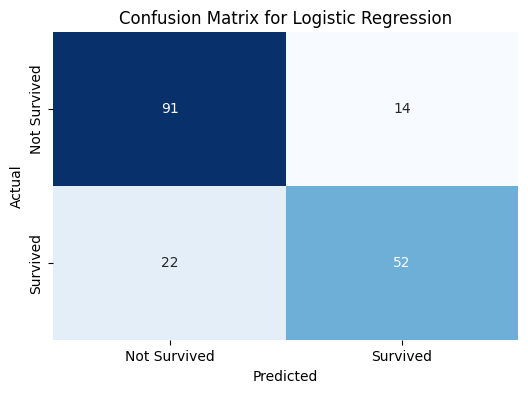


Training K-Nearest Neighbors...
K-Nearest Neighbors - Accuracy: 0.7989, Precision: 0.7714, Recall: 0.7297, F1-Score: 0.7500


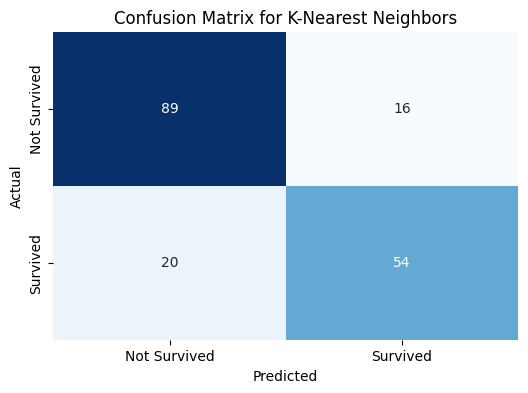


Training Support Vector Machine...
Support Vector Machine - Accuracy: 0.8156, Precision: 0.8060, Recall: 0.7297, F1-Score: 0.7660


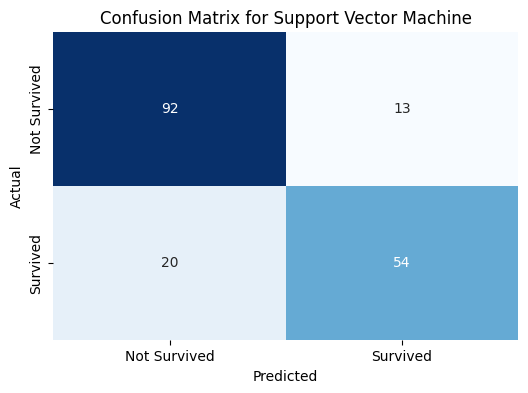

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

# Initialize models
models = {
    "Logistic Regression": LogisticRegression(random_state=42, solver='liblinear'),
    "K-Nearest Neighbors": KNeighborsClassifier(),
    "Support Vector Machine": SVC(random_state=42)
}

results = {}

for name, model in models.items():
    print(f"\nTraining {name}...")
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    # Evaluate model
    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred)
    recall = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    cm = confusion_matrix(y_test, y_pred)

    results[name] = {
        "accuracy": accuracy,
        "precision": precision,
        "recall": recall,
        "f1_score": f1,
        "confusion_matrix": cm
    }

    print(f"{name} - Accuracy: {accuracy:.4f}, Precision: {precision:.4f}, Recall: {recall:.4f}, F1-Score: {f1:.4f}")

    # Plot confusion matrix
    plt.figure(figsize=(6, 4))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", cbar=False,
                xticklabels=['Not Survived', 'Survived'],
                yticklabels=['Not Survived', 'Survived'])
    plt.title(f"Confusion Matrix for {name}")
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.show()


## Model Comparison

After training and evaluating individual models, this section compiles their performance metrics into a single table and visualizes them for easy comparison, helping us identify the best-performing model.

## Model Comparison


Model Performance Comparison:


/tmp/ipykernel_1982/2398964948.py:4: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  metrics_df = pd.concat([


,Model,Accuracy,Precision,Recall,F1-Score
0,Logistic Regression,0.798883,0.787879,0.702703,0.742857
1,K-Nearest Neighbors,0.798883,0.771429,0.729730,0.750000
2,Support Vector Machine,0.815642,0.805970,0.729730,0.765957


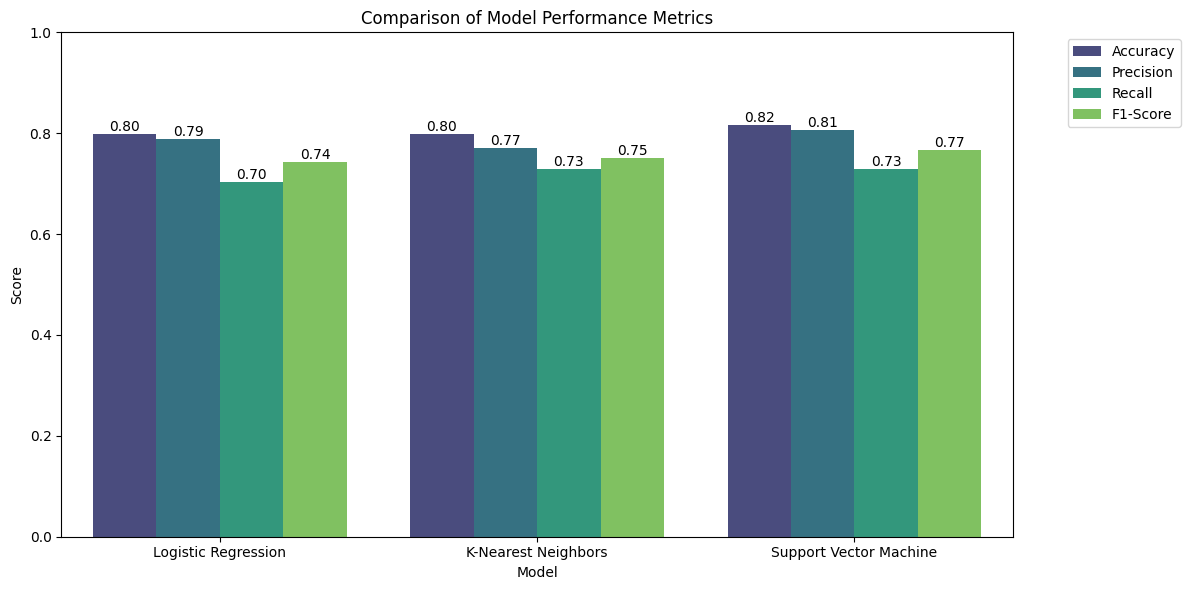

In [ ]:
metrics_df = pd.DataFrame(columns=['Model', 'Accuracy', 'Precision', 'Recall', 'F1-Score'])

for name, metrics in results.items():
    metrics_df = pd.concat([
        metrics_df,
        pd.DataFrame([{
            'Model': name,
            'Accuracy': metrics['accuracy'],
            'Precision': metrics['precision'],
            'Recall': metrics['recall'],
            'F1-Score': metrics['f1_score']
        }])
    ], ignore_index=True)

print("\nModel Performance Comparison:")
display(metrics_df)

# Visualize model performance
metrics_df_melted = metrics_df.melt(id_vars='Model', var_name='Metric', value_name='Score')

plt.figure(figsize=(12, 6))
ax = sns.barplot(x='Model', y='Score', hue='Metric', data=metrics_df_melted, palette='viridis')
plt.title('Comparison of Model Performance Metrics')
plt.ylabel('Score')
plt.ylim(0, 1) # Metrics are between 0 and 1
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')

# Add labels to the bars
for container in ax.containers:
    ax.bar_label(container, fmt='%.2f', label_type='edge')

plt.tight_layout()
plt.show()

## Model Training and Evaluation

In [ ]:
from sklearn.model_selection import train_test_split

# Define features (X) and target (y)
X = df.drop('Survived', axis=1)
y = df['Survived']

# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"X_train shape: {X_train.shape}")
print(f"X_test shape: {X_test.shape}")
print(f"y_train shape: {y_train.shape}")
print(f"y_test shape: {y_test.shape}")

X_train shape: (712, 8)
X_test shape: (179, 8)
y_train shape: (712,)
y_test shape: (179,)



Training Logistic Regression...
Logistic Regression - Accuracy: 0.7989, Precision: 0.7879, Recall: 0.7027, F1-Score: 0.7429


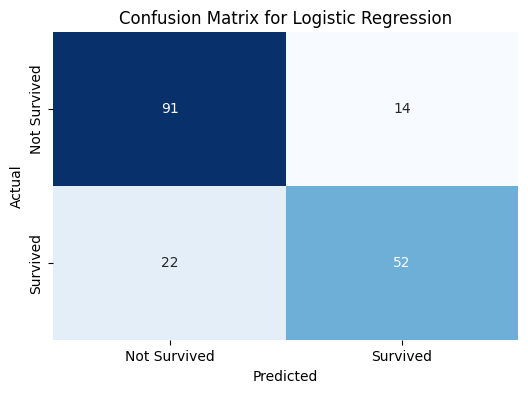


Training K-Nearest Neighbors...
K-Nearest Neighbors - Accuracy: 0.7989, Precision: 0.7714, Recall: 0.7297, F1-Score: 0.7500


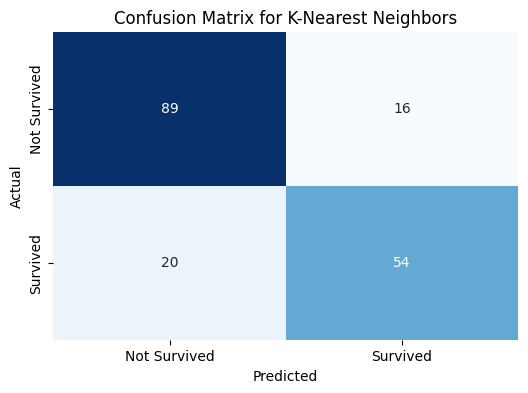


Training Support Vector Machine...
Support Vector Machine - Accuracy: 0.8156, Precision: 0.8060, Recall: 0.7297, F1-Score: 0.7660


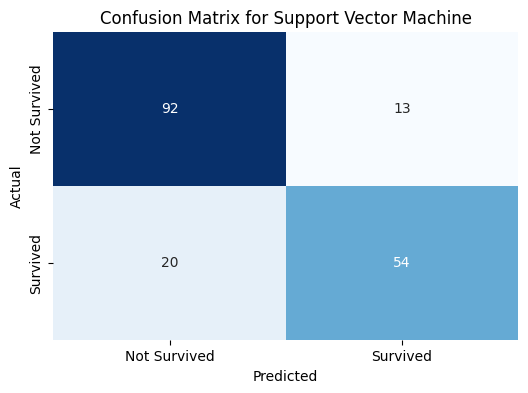

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

# Initialize models
models = {
    "Logistic Regression": LogisticRegression(random_state=42, solver='liblinear'),
    "K-Nearest Neighbors": KNeighborsClassifier(),
    "Support Vector Machine": SVC(random_state=42)
}

results = {}

for name, model in models.items():
    print(f"\nTraining {name}...")
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    # Evaluate model
    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred)
    recall = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    cm = confusion_matrix(y_test, y_pred)

    results[name] = {
        "accuracy": accuracy,
        "precision": precision,
        "recall": recall,
        "f1_score": f1,
        "confusion_matrix": cm
    }

    print(f"{name} - Accuracy: {accuracy:.4f}, Precision: {precision:.4f}, Recall: {recall:.4f}, F1-Score: {f1:.4f}")

    # Plot confusion matrix
    plt.figure(figsize=(6, 4))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", cbar=False,
                xticklabels=['Not Survived', 'Survived'],
                yticklabels=['Not Survived', 'Survived'])
    plt.title(f"Confusion Matrix for {name}")
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.show()


## Model Comparison


Model Performance Comparison:


/tmp/ipykernel_1982/4194178601.py:4: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  metrics_df = pd.concat([


,Model,Accuracy,Precision,Recall,F1-Score
0,Logistic Regression,0.798883,0.787879,0.702703,0.742857
1,K-Nearest Neighbors,0.798883,0.771429,0.729730,0.750000
2,Support Vector Machine,0.815642,0.805970,0.729730,0.765957


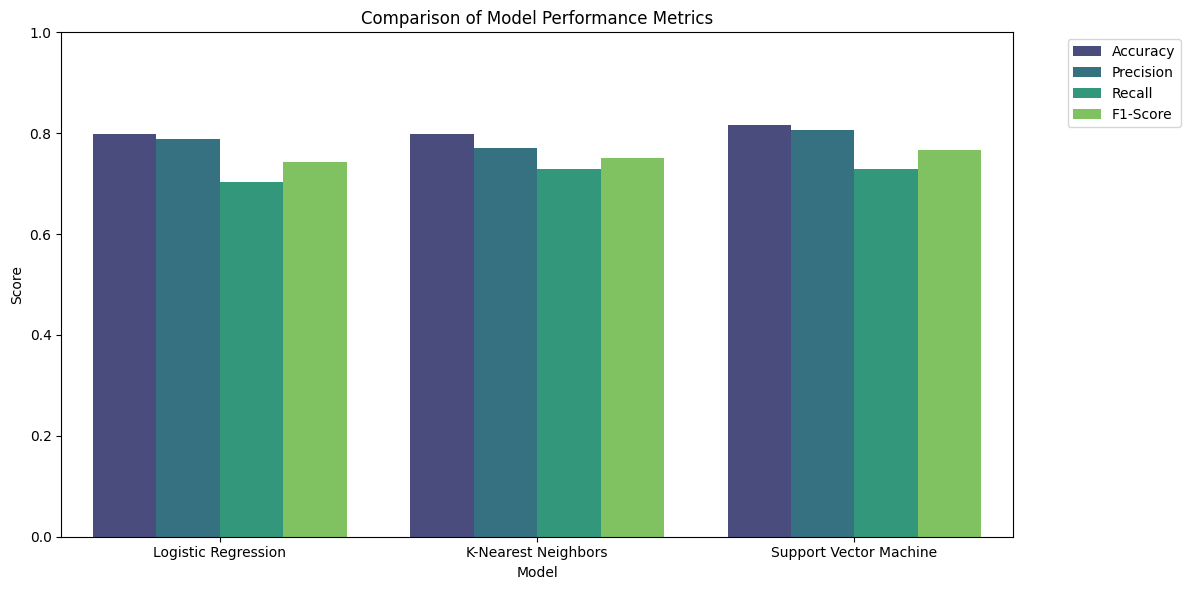

In [ ]:
metrics_df = pd.DataFrame(columns=['Model', 'Accuracy', 'Precision', 'Recall', 'F1-Score'])

for name, metrics in results.items():
    metrics_df = pd.concat([
        metrics_df,
        pd.DataFrame([{
            'Model': name,
            'Accuracy': metrics['accuracy'],
            'Precision': metrics['precision'],
            'Recall': metrics['recall'],
            'F1-Score': metrics['f1_score']
        }])
    ], ignore_index=True)

print("\nModel Performance Comparison:")
display(metrics_df)

# Visualize model performance
metrics_df_melted = metrics_df.melt(id_vars='Model', var_name='Metric', value_name='Score')

plt.figure(figsize=(12, 6))
sns.barplot(x='Model', y='Score', hue='Metric', data=metrics_df_melted, palette='viridis')
plt.title('Comparison of Model Performance Metrics')
plt.ylabel('Score')
plt.ylim(0, 1) # Metrics are between 0 and 1
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

## Model Training and Evaluation

In [ ]:
from sklearn.model_selection import train_test_split

# Define features (X) and target (y)
X = df.drop('Survived', axis=1)
y = df['Survived']

# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"X_train shape: {X_train.shape}")
print(f"X_test shape: {X_test.shape}")
print(f"y_train shape: {y_train.shape}")
print(f"y_test shape: {y_test.shape}")

X_train shape: (712, 8)
X_test shape: (179, 8)
y_train shape: (712,)
y_test shape: (179,)



Training Logistic Regression...
Logistic Regression - Accuracy: 0.7989, Precision: 0.7879, Recall: 0.7027, F1-Score: 0.7429


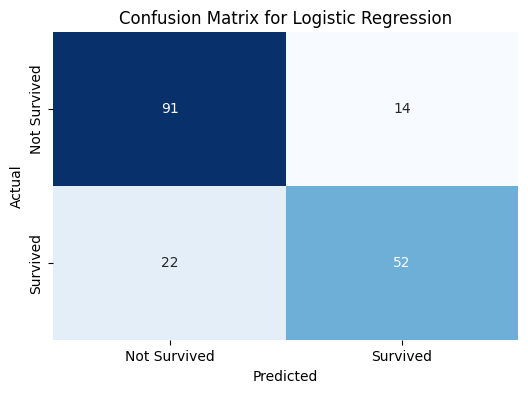


Training K-Nearest Neighbors...
K-Nearest Neighbors - Accuracy: 0.7989, Precision: 0.7714, Recall: 0.7297, F1-Score: 0.7500


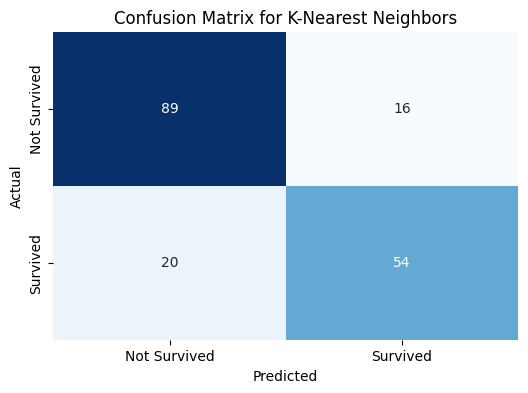


Training Support Vector Machine...
Support Vector Machine - Accuracy: 0.8156, Precision: 0.8060, Recall: 0.7297, F1-Score: 0.7660


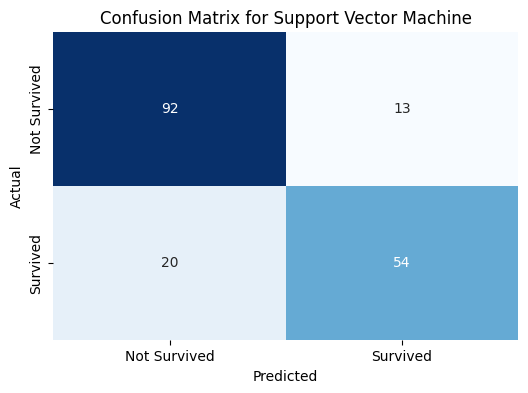

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

# Initialize models
models = {
    "Logistic Regression": LogisticRegression(random_state=42, solver='liblinear'),
    "K-Nearest Neighbors": KNeighborsClassifier(),
    "Support Vector Machine": SVC(random_state=42)
}

results = {}

for name, model in models.items():
    print(f"\nTraining {name}...")
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    # Evaluate model
    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred)
    recall = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    cm = confusion_matrix(y_test, y_pred)

    results[name] = {
        "accuracy": accuracy,
        "precision": precision,
        "recall": recall,
        "f1_score": f1,
        "confusion_matrix": cm
    }

    print(f"{name} - Accuracy: {accuracy:.4f}, Precision: {precision:.4f}, Recall: {recall:.4f}, F1-Score: {f1:.4f}")

    # Plot confusion matrix
    plt.figure(figsize=(6, 4))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", cbar=False,
                xticklabels=['Not Survived', 'Survived'],
                yticklabels=['Not Survived', 'Survived'])
    plt.title(f"Confusion Matrix for {name}")
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.show()


## Model Comparison


Model Performance Comparison:


/tmp/ipykernel_1982/2398964948.py:4: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  metrics_df = pd.concat([


,Model,Accuracy,Precision,Recall,F1-Score
0,Logistic Regression,0.798883,0.787879,0.702703,0.742857
1,K-Nearest Neighbors,0.798883,0.771429,0.729730,0.750000
2,Support Vector Machine,0.815642,0.805970,0.729730,0.765957


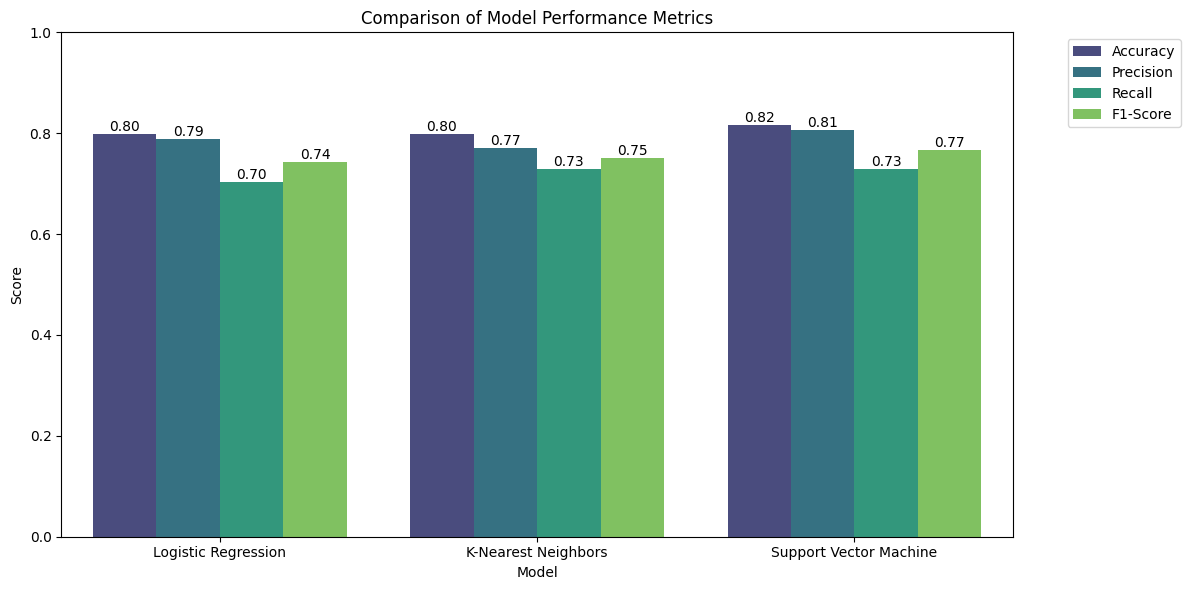

In [ ]:
metrics_df = pd.DataFrame(columns=['Model', 'Accuracy', 'Precision', 'Recall', 'F1-Score'])

for name, metrics in results.items():
    metrics_df = pd.concat([
        metrics_df,
        pd.DataFrame([{
            'Model': name,
            'Accuracy': metrics['accuracy'],
            'Precision': metrics['precision'],
            'Recall': metrics['recall'],
            'F1-Score': metrics['f1_score']
        }])
    ], ignore_index=True)

print("\nModel Performance Comparison:")
display(metrics_df)

# Visualize model performance
metrics_df_melted = metrics_df.melt(id_vars='Model', var_name='Metric', value_name='Score')

plt.figure(figsize=(12, 6))
ax = sns.barplot(x='Model', y='Score', hue='Metric', data=metrics_df_melted, palette='viridis')
plt.title('Comparison of Model Performance Metrics')
plt.ylabel('Score')
plt.ylim(0, 1) # Metrics are between 0 and 1
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')

# Add labels to the bars
for container in ax.containers:
    ax.bar_label(container, fmt='%.2f', label_type='edge')

plt.tight_layout()
plt.show()

## Making Predictions with the Best Model

After comparing the models, we can select the best-performing one to make predictions on new, unseen data. Based on our evaluation, the Support Vector Machine (SVM) model achieved the highest F1-Score, making it a suitable candidate for deployment.

In [ ]:
# Identify the best model based on F1-Score from the results dictionary
best_model_name = metrics_df.loc[metrics_df['F1-Score'].idxmax()]['Model']
best_model = models[best_model_name]

print(f"The best performing model is: {best_model_name}")

# For demonstration, let's use a few samples from the test set to predict
# In a real-world scenario, you would use genuinely new, unseen data.

# Select the first 5 samples from the test features and their true labels
sample_X = X_test.head(5)
sample_y_true = y_test.head(5)

# Make predictions using the best model
sample_y_pred = best_model.predict(sample_X)

# Create a DataFrame to display the predictions alongside the true values
predictions_df = pd.DataFrame({
    'Features': sample_X.apply(lambda x: x.to_dict(), axis=1),
    'Actual Survived': sample_y_true,
    'Predicted Survived': sample_y_pred
})

print("\nSample Predictions:")
display(predictions_df)


The best performing model is: Support Vector Machine

Sample Predictions:


,Features,Actual Survived,Predicted Survived
709,"{'Pclass': 3, 'Age': -0.10463740114712752, 'Si...",1,0
439,"{'Pclass': 2, 'Age': 0.12591212881674602, 'Sib...",0,0
840,"{'Pclass': 3, 'Age': -0.719436147717457, 'SibS...",0,0
720,"{'Pclass': 2, 'Age': -1.7953339542155335, 'Sib...",1,1
39,"{'Pclass': 3, 'Age': -1.180535207645204, 'SibS...",1,1
